# GURGAON REAL ESTATE

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "nikhilmehrahr26/gurgaon-real-estate-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 329k/329k [00:00<00:00, 63.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nikhilmehrahr26/gurgaon-real-estate-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['data of gurugram real Estate.csv']


In [ ]:
import os

files = os.listdir(path)
print(files)

['data of gurugram real Estate.csv']


In [ ]:
import pandas as pd

file_path = os.path.join(path, "Gurgaon_Real_Estate_Data.csv")

df = pd.read_csv(file_path)

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/nikhilmehrahr26/gurgaon-real-estate-dataset/versions/1/Gurgaon_Real_Estate_Data.csv'

In [ ]:
import os

print("Dataset path:")
print(path)

print("\nFiles inside dataset:")
for file in os.listdir(path):
    print(file)

Dataset path:
/root/.cache/kagglehub/datasets/nikhilmehrahr26/gurgaon-real-estate-dataset/versions/1

Files inside dataset:
data of gurugram real Estate.csv


In [ ]:
import os

csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/root/.cache/kagglehub/datasets/nikhilmehrahr26/gurgaon-real-estate-dataset/versions/1/data of gurugram real Estate.csv


In [ ]:
import pandas as pd

file_path = "/root/.cache/kagglehub/datasets/nikhilmehrahr26/gurgaon-real-estate-dataset/versions/1/data of gurugram real Estate.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (19515, 12)


In [ ]:
print(df.head())

        Price              Status  Area Rate per sqft  \
0  10700000.0  Under Construction  1138        9,450    
1  14400000.0  Under Construction  1528        9,450    
2  10700000.0  Under Construction  1138        9,450    
3  40000000.0       Ready to move  4500        8,888    
4  24000000.0  Under Construction  1800       13,333    

                                       Property Type   Locality  \
0       2 BHK Apartment in M3M Antalya Hills Phase I  Sector 79   
1       3 BHK Apartment in M3M Antalya Hills Phase I  Sector 79   
2       2 BHK Apartment in M3M Antalya Hills Phase I  Sector 79   
3                            4 BHK Independent Floor  Sector 57   
4  3 BHK Independent Floor in Anant Raj Estate Plots  Sector 63   

                     Builder Name         RERA Approval  BHK_Count  \
0                            home      Approved by RERA        2.0   
1             Property In Gurgaon      Approved by RERA        3.0   
2  properties for sale in Gurgaon      Appro

In [ ]:
print(df.columns.tolist())

['Price', 'Status', 'Area', 'Rate per sqft', 'Property Type', 'Locality', 'Builder Name', 'RERA Approval', 'BHK_Count', 'Socity', 'Company Name', 'Flat Type']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price          19515 non-null  object 
 1   Status         19515 non-null  object 
 2   Area           19515 non-null  int64  
 3   Rate per sqft  19515 non-null  object 
 4   Property Type  19515 non-null  object 
 5   Locality       19515 non-null  object 
 6   Builder Name   19515 non-null  object 
 7   RERA Approval  19515 non-null  object 
 8   BHK_Count      19515 non-null  float64
 9   Socity         19515 non-null  object 
 10  Company Name   19515 non-null  object 
 11  Flat Type      19515 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 1.8+ MB


In [ ]:
# Check unique examples from important columns

print("Price examples:")
print(df["Price"].head(10).tolist())

print("\nRate per sqft examples:")
print(df["Rate per sqft"].head(10).tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Price examples:
['10700000.0', '14400000.0', '10700000.0', '40000000.0', '24000000.0', '63800000.0', '4500000.0', '4500000.0', '9000000.0', '74900000.0']

Rate per sqft examples:
['9,450 ', '9,450 ', '9,450 ', '8,888 ', '13,333 ', '28,000 ', '4,891 ', '4,500 ', '7,200 ', '19,736 ']

Missing values:
Price            0
Status           0
Area             0
Rate per sqft    0
Property Type    0
Locality         0
Builder Name     0
RERA Approval    0
BHK_Count        0
Socity           0
Company Name     0
Flat Type        0
dtype: int64

Duplicate rows:
5292


In [ ]:
# Convert Price to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Remove commas and convert Rate per sqft to numeric
df["Rate per sqft"] = (
    df["Rate per sqft"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Rate per sqft"] = pd.to_numeric(
    df["Rate per sqft"],
    errors="coerce"
)

print(df[["Price", "Rate per sqft"]].dtypes)

Price            float64
Rate per sqft      int64
dtype: object


In [ ]:
print(df[["Price", "Rate per sqft"]].dtypes)
print(df.isnull().sum())

Price            float64
Rate per sqft      int64
dtype: object
Price            1
Status           0
Area             0
Rate per sqft    0
Property Type    0
Locality         0
Builder Name     0
RERA Approval    0
BHK_Count        0
Socity           0
Company Name     0
Flat Type        0
dtype: int64


In [ ]:
# Remove rows where Price is missing
df = df.dropna(subset=["Price"])

print("New shape:", df.shape)
print("Missing Price:", df["Price"].isnull().sum())

New shape: (19514, 12)
Missing Price: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5292


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Shape after removing duplicates: (14222, 12)
Remaining duplicates: 0


In [ ]:
print("Price statistics:")
print(df["Price"].describe())

print("\nArea statistics:")
print(df["Area"].describe())

print("\nBHK statistics:")
print(df["BHK_Count"].describe())

print("\nZero/negative values:")
print("Price <= 0:", (df["Price"] <= 0).sum())
print("Area <= 0:", (df["Area"] <= 0).sum())
print("BHK <= 0:", (df["BHK_Count"] <= 0).sum())

Price statistics:
count    1.422200e+04
mean     3.995657e+07
std      5.755396e+07
min      1.000000e+05
25%      1.410000e+07
50%      2.620000e+07
75%      4.550000e+07
max      1.226300e+09
Name: Price, dtype: float64

Area statistics:
count     14222.000000
mean       2621.927718
std       11125.670369
min          60.000000
25%        1424.250000
50%        2015.000000
75%        2841.750000
max      958320.000000
Name: Area, dtype: float64

BHK statistics:
count    14222.000000
mean         3.266418
std          5.496817
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max        132.000000
Name: BHK_Count, dtype: float64

Zero/negative values:
Price <= 0: 0
Area <= 0: 0
BHK <= 0: 998


In [ ]:
# Remove records with invalid BHK values
df = df[df["BHK_Count"] > 0].copy()

print("Shape after removing invalid BHK:", df.shape)
print("Minimum BHK:", df["BHK_Count"].min())

Shape after removing invalid BHK: (13224, 12)
Minimum BHK: 1.0


In [ ]:
# Calculate reasonable boundaries
area_low = df["Area"].quantile(0.01)
area_high = df["Area"].quantile(0.99)

bhk_low = df["BHK_Count"].quantile(0.01)
bhk_high = df["BHK_Count"].quantile(0.99)

price_low = df["Price"].quantile(0.01)
price_high = df["Price"].quantile(0.99)

print("Area range:", area_low, "to", area_high)
print("BHK range:", bhk_low, "to", bhk_high)
print("Price range:", price_low, "to", price_high)

Area range: 462.23 to 9000.0
BHK range: 1.0 to 6.0
Price range: 2048920.0 to 286000000.0


In [ ]:
# Keep realistic observations using 1st–99th percentile ranges

df = df[
    (df["Area"] >= area_low) &
    (df["Area"] <= area_high) &
    (df["BHK_Count"] >= bhk_low) &
    (df["BHK_Count"] <= bhk_high) &
    (df["Price"] >= price_low) &
    (df["Price"] <= price_high)
].copy()

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (12759, 12)


In [ ]:
print(df[["Price", "Area", "BHK_Count"]].describe())

              Price          Area     BHK_Count
count  1.275900e+04  12759.000000  12759.000000
mean   3.594437e+07   2392.153852      3.183322
std    3.160735e+07   1345.976167      0.822373
min    2.052000e+06    475.000000      1.000000
25%    1.520000e+07   1488.000000      3.000000
50%    2.700000e+07   2064.000000      3.000000
75%    4.500000e+07   2822.000000      4.000000
max    2.860000e+08   9000.000000      6.000000


In [ ]:
df.to_csv("gurgaon_real_estate_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


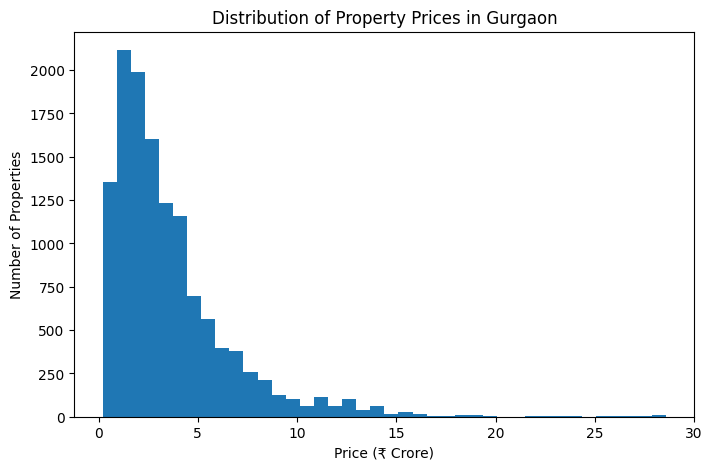

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Price"] / 10000000, bins=40)

plt.xlabel("Price (₹ Crore)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Prices in Gurgaon")

plt.show()

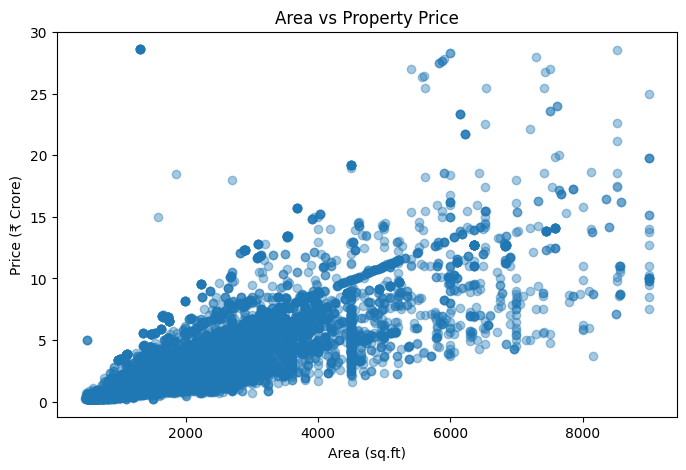

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Area"],
    df["Price"] / 10000000,
    alpha=0.4
)

plt.xlabel("Area (sq.ft)")
plt.ylabel("Price (₹ Crore)")
plt.title("Area vs Property Price")

plt.show()

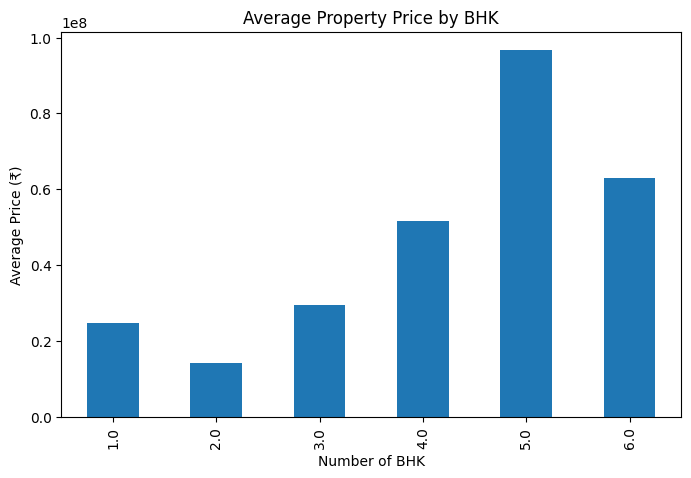

In [ ]:
plt.figure(figsize=(8,5))

df.groupby("BHK_Count")["Price"].mean().plot(kind="bar")

plt.xlabel("Number of BHK")
plt.ylabel("Average Price (₹)")
plt.title("Average Property Price by BHK")

plt.show()

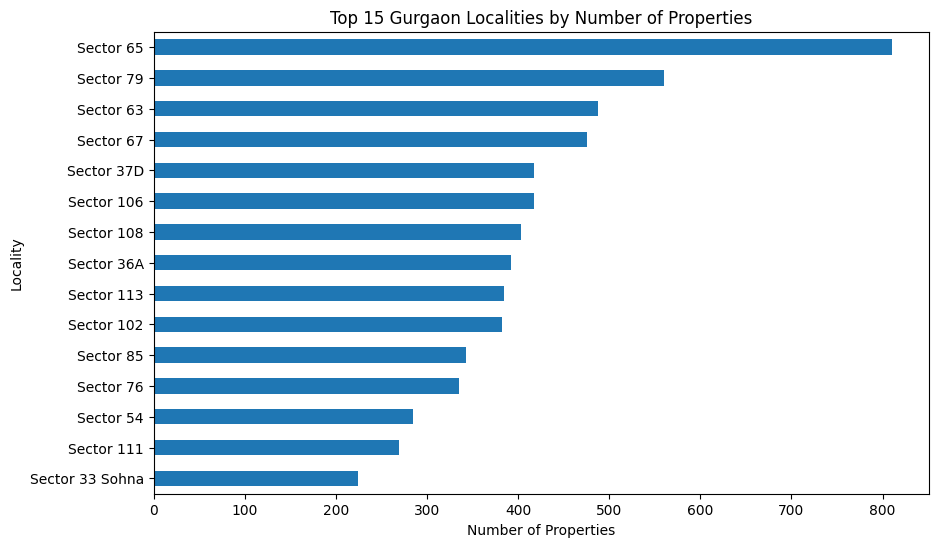

In [ ]:
top_locations = df["Locality"].value_counts().head(15)

plt.figure(figsize=(10,6))

top_locations.sort_values().plot(kind="barh")

plt.xlabel("Number of Properties")
plt.ylabel("Locality")
plt.title("Top 15 Gurgaon Localities by Number of Properties")

plt.show()

In [ ]:
location_stats = (
    df.groupby("Locality")
    .agg(
        Property_Count=("Price", "count"),
        Average_Price=("Price", "mean")
    )
)

location_stats = location_stats[
    location_stats["Property_Count"] >= 30
]

location_stats = location_stats.sort_values(
    "Average_Price",
    ascending=False
).head(15)

print(location_stats)

                   Property_Count  Average_Price
Locality                                        
Sector 53                     132   8.913030e+07
Sector 54                     285   8.813474e+07
Sector 24                      56   7.521429e+07
Sector 76                     335   6.869350e+07
Sector 62                     208   6.759244e+07
Sector 58                      89   6.264719e+07
Sector 65                     810   6.242988e+07
DLF Phase 4                    67   6.071194e+07
Sector 72                     100   5.972000e+07
Sector 48                     130   5.736806e+07
Sector 66                     146   5.156712e+07
DLF Phase 2                    67   5.142985e+07
Sector 28                      76   4.985658e+07
South City I                   43   4.817209e+07
Sector 22 Gurgaon              61   4.808852e+07


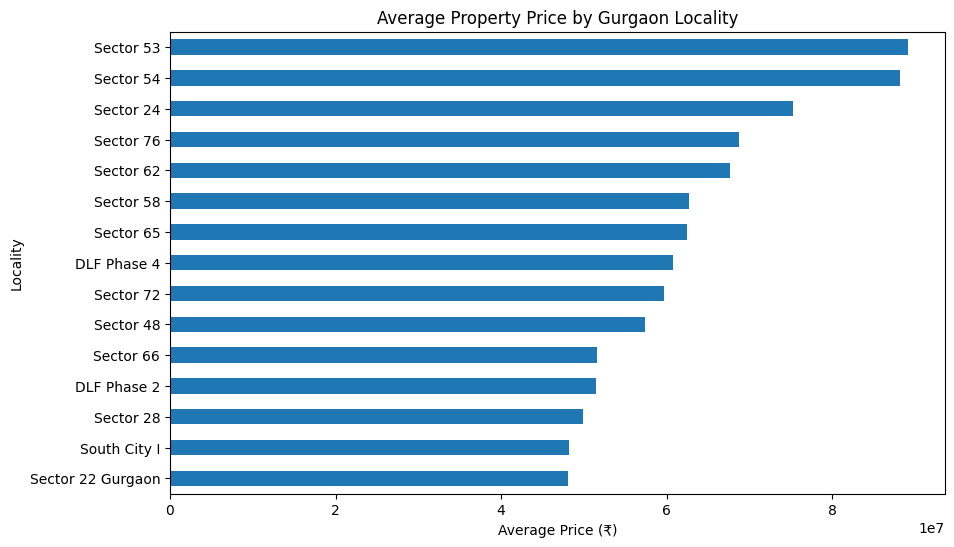

In [ ]:
plt.figure(figsize=(10,6))

location_stats["Average_Price"].sort_values().plot(kind="barh")

plt.xlabel("Average Price (₹)")
plt.ylabel("Locality")
plt.title("Average Property Price by Gurgaon Locality")

plt.show()

In [ ]:
categorical_columns = [
    "Status",
    "Property Type",
    "Locality",
    "Builder Name",
    "RERA Approval",
    "Socity",
    "Company Name",
    "Flat Type"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print("Unique values:", df[col].nunique())


Status:
Unique values: 4

Property Type:
Unique values: 1634

Locality:
Unique values: 207

Builder Name:
Unique values: 672

RERA Approval:
Unique values: 2

Socity:
Unique values: 855

Company Name:
Unique values: 224

Flat Type:
Unique values: 6


In [ ]:
features = [
    "Area",
    "BHK_Count",
    "Status",
    "Property Type",
    "Locality",
    "RERA Approval",
    "Flat Type"
]

X = df[features]
y = df["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12759, 7)
y shape: (12759,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10207, 7)
Testing data: (2552, 7)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = [
    "Area",
    "BHK_Count"
]

categorical_features = [
    "Status",
    "Property Type",
    "Locality",
    "RERA Approval",
    "Flat Type"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [ ]:
linear_predictions = linear_model.predict(X_test)

print(linear_predictions[:5])

[2.32923610e+08 1.29361753e+07 5.89758097e+07 4.29000270e+07
 1.41622613e+07]


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_linear = mean_absolute_error(
    y_test,
    linear_predictions
)

rmse_linear = mean_squared_error(
    y_test,
    linear_predictions
) ** 0.5

r2_linear = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 6665040.826683581
RMSE: 13786695.23243547
R²  : 0.8174268085964691


In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print(random_forest_predictions[:5])


Random Forest predictions generated successfully!
[2.08592000e+08 1.52332956e+07 5.03355495e+07 4.39000000e+07
 1.17817454e+07]


In [ ]:
mae_rf = mean_absolute_error(y_test, random_forest_predictions)

rmse_rf = mean_squared_error(
    y_test,
    random_forest_predictions
) ** 0.5

r2_rf = r2_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 5958989.868346928
RMSE: 13597008.5996623
R²  : 0.8224161770063008


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [ ]:
gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

print("Gradient Boosting predictions generated successfully!")
print(gradient_boosting_predictions[:5])

Gradient Boosting predictions generated successfully!
[1.78550718e+08 2.48037385e+07 4.54981101e+07 3.83153458e+07
 1.95470999e+07]


In [ ]:
mae_gb = mean_absolute_error(y_test, gradient_boosting_predictions)

rmse_gb = mean_squared_error(
    y_test,
    gradient_boosting_predictions
) ** 0.5

r2_gb = r2_score(
    y_test,
    gradient_boosting_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
-------------------------
MAE : 10843436.966402624
RMSE: 17128969.094523653
R²  : 0.7181752643736223


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    "R²": [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

print(model_comparison)

               Model           MAE          RMSE        R²
0  Linear Regression  6.665041e+06  1.378670e+07  0.817427
1      Random Forest  5.958990e+06  1.359701e+07  0.822416
2  Gradient Boosting  1.084344e+07  1.712897e+07  0.718175


In [ ]:
model_comparison_display = model_comparison.copy()

model_comparison_display["MAE"] = (
    model_comparison_display["MAE"] / 10000000
)

model_comparison_display["RMSE"] = (
    model_comparison_display["RMSE"] / 10000000
)

model_comparison_display = model_comparison_display.round(4)

print("Model Comparison")
print("----------------")
print(model_comparison_display)

Model Comparison
----------------
               Model     MAE    RMSE      R²
0  Linear Regression  0.6665  1.3787  0.8174
1      Random Forest  0.5959  1.3597  0.8224
2  Gradient Boosting  1.0843  1.7129  0.7182


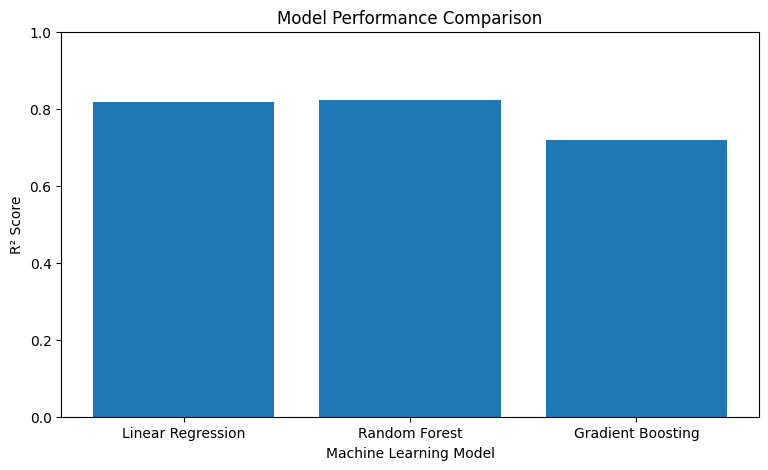

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R²"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)

plt.show()

In [ ]:
new_property = pd.DataFrame({
    "Area": [2000],
    "BHK_Count": [3],
    "Status": ["Ready to Move"],
    "Property Type": ["Apartment"],
    "Locality": ["Sector 57"],
    "RERA Approval": ["Yes"],
    "Flat Type": ["Apartment"]
})

predicted_price = random_forest_model.predict(new_property)

print("Predicted Property Price:")
print(f"₹{predicted_price[0]:,.2f}")

Predicted Property Price:
₹18,103,518.94


In [ ]:
import joblib

joblib.dump(
    random_forest_model,
    "gurgaon_real_estate_random_forest.pkl"
)

print("Final Random Forest model saved successfully!")

Final Random Forest model saved successfully!


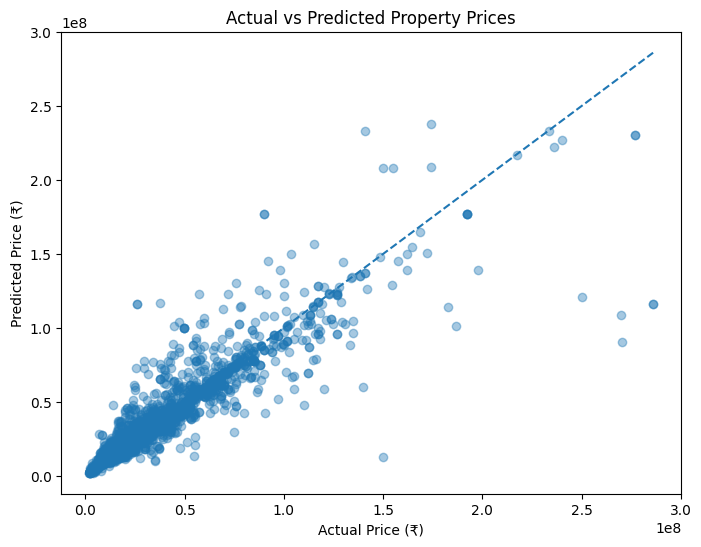

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.4
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted Property Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [ ]:
# Get the fitted preprocessing step
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance from Random Forest
importances = random_forest_model.named_steps["model"].feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance_df.head(15))

                                                Feature  Importance
0                                             num__Area    0.684056
1633                            cat__Locality_Sector 54    0.019899
1037  cat__Property Type_4 BHK Apartment in DLF The ...    0.015748
1620                            cat__Locality_Sector 42    0.013994
1714                           cat__Flat Type_Apartment    0.012175
1454  cat__Property Type_5 BHK Villa in B kumar and ...    0.010540
1632                            cat__Locality_Sector 53    0.009802
136   cat__Property Type_2 BHK Apartment in M3M Capital    0.009743
1646                            cat__Locality_Sector 65    0.006526
1                                        num__BHK_Count    0.006173
1034  cat__Property Type_4 BHK Apartment in DLF The ...    0.006084
1377  cat__Property Type_5 BHK Apartment in DLF The ...    0.005487
748   cat__Property Type_3 BHK Apartment in Tulip Mo...    0.005399
1643                            cat__Locality_Se

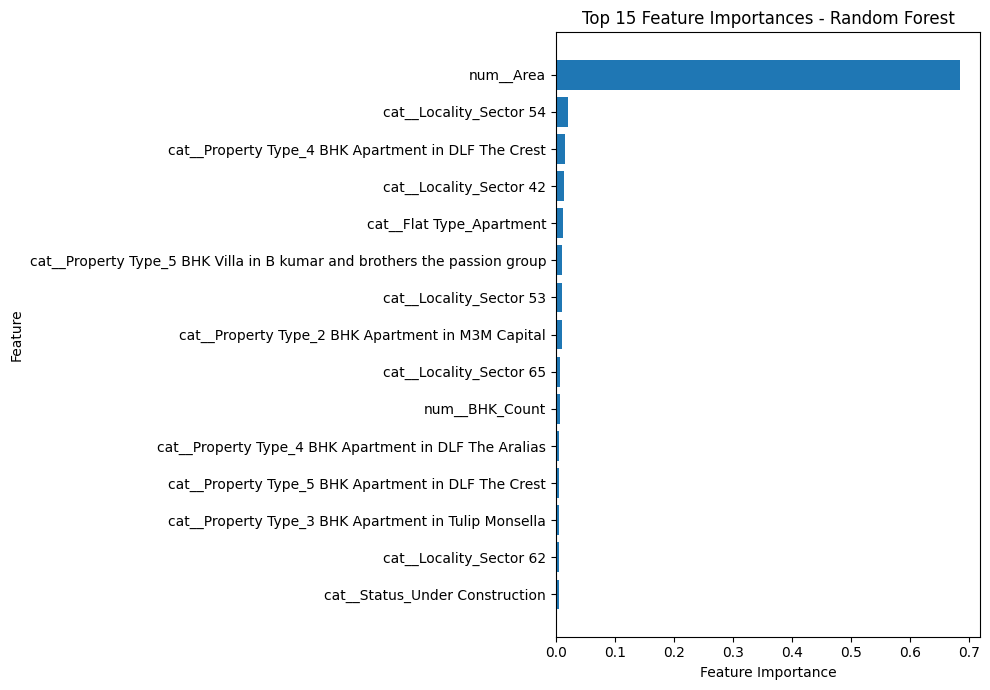

In [ ]:
top_features = feature_importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
# Save model comparison results
model_comparison.to_csv(
    "gurgaon_model_comparison.csv",
    index=False
)

# Save the cleaned dataset again
df.to_csv(
    "gurgaon_real_estate_cleaned.csv",
    index=False
)

print("Model comparison saved successfully!")
print("Cleaned dataset saved successfully!")

Model comparison saved successfully!
Cleaned dataset saved successfully!
